In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Column names for C-MAPSS FD001
cols = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]

# Load data (relative path from notebooks/ folder)
df = pd.read_csv('../data/train_FD001.txt', sep=r'\s+', header=None, names=cols)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:", df.isnull().sum().sum())
print("\nUnique engines:", df['unit'].nunique())

Shape: (20631, 26)

First 5 rows:
   unit  cycle     op1     op2    op3      s1      s2       s3       s4  \
0     1      1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60   
1     1      2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14   
2     1      3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20   
3     1      4  0.0007  0.0000  100.0  518.67  642.35  1582.79  1401.87   
4     1      5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85  1406.22   

      s5  ...     s12      s13      s14     s15   s16  s17   s18    s19  \
0  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388  100.0   
1  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03  392  2388  100.0   
2  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03  390  2388  100.0   
3  14.62  ...  522.86  2388.08  8133.83  8.3682  0.03  392  2388  100.0   
4  14.62  ...  522.19  2388.04  8133.80  8.4294  0.03  393  2388  100.0   

     s20      s21  
0  39.06  23.4190  
1  39.00  23.4236  
2  3

In [3]:
# Get the last cycle (failure point) for each engine
max_cycle = df.groupby('unit')['cycle'].max().reset_index()
max_cycle.columns = ['unit', 'max_cycle']

# Merge back and compute RUL
df = df.merge(max_cycle, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']
df.drop('max_cycle', axis=1, inplace=True)

print("RUL column created.\n")
print(df[['unit', 'cycle', 'RUL']].head(10))
print("\nRUL statistics:")
print(df['RUL'].describe())

RUL column created.

   unit  cycle  RUL
0     1      1  191
1     1      2  190
2     1      3  189
3     1      4  188
4     1      5  187
5     1      6  186
6     1      7  185
7     1      8  184
8     1      9  183
9     1     10  182

RUL statistics:
count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64


In [4]:
sensor_cols = [f's{i}' for i in range(1, 22)]
constant_sensors = [col for col in sensor_cols if df[col].std() == 0]

print("Constant sensors to drop:", constant_sensors)

df.drop(columns=constant_sensors, inplace=True)

active_sensors = [col for col in df.columns if col.startswith('s')]
print(f"\nActive sensors ({len(active_sensors)}):", active_sensors)
print("\nFinal shape:", df.shape)

Constant sensors to drop: ['s1', 's10', 's18', 's19']

Active sensors (17): ['s2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's20', 's21']

Final shape: (20631, 23)


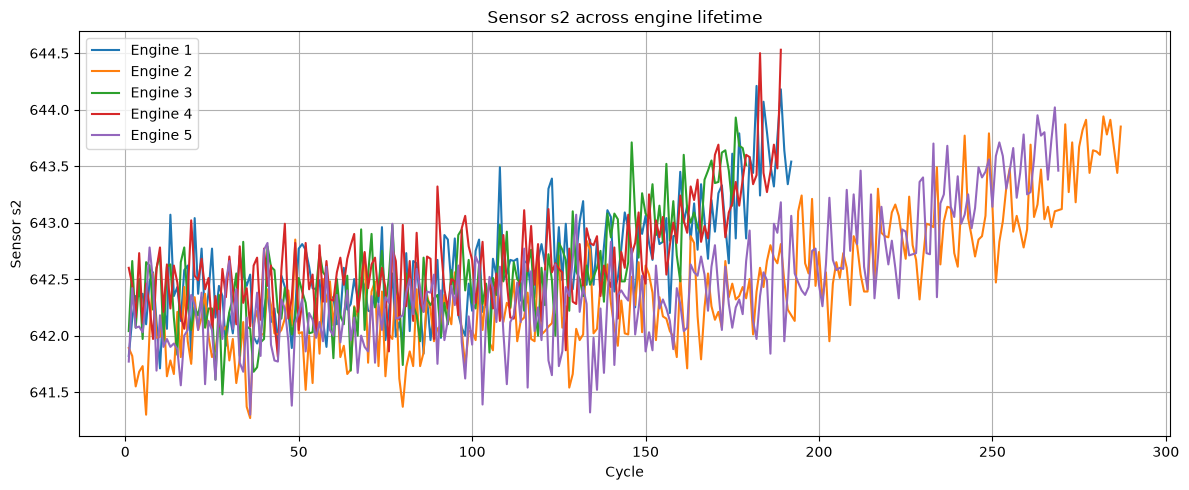

In [5]:
plt.figure(figsize=(12, 5))
for engine_id in [1, 2, 3, 4, 5]:
    engine_data = df[df['unit'] == engine_id]
    plt.plot(engine_data['cycle'], engine_data['s2'], label=f'Engine {engine_id}')

plt.xlabel('Cycle')
plt.ylabel('Sensor s2')
plt.title('Sensor s2 across engine lifetime')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/sensor_exploration.png', dpi=120)
plt.show()

In [6]:
df.to_csv('../outputs/clean_data.csv', index=False)
print("Saved to outputs/clean_data.csv")
print("Final shape:", df.shape)
print("Columns:", list(df.columns))

Saved to outputs/clean_data.csv
Final shape: (20631, 23)
Columns: ['unit', 'cycle', 'op1', 'op2', 'op3', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's20', 's21', 'RUL']


In [7]:
# Get unique engine IDs
all_units = sorted(df['unit'].unique())
print(f"Total engines: {len(all_units)}")

# Use a fixed random split: 70 engines for train, 30 for test
np.random.seed(42)
np.random.shuffle(all_units)

train_units = all_units[:70]
test_units = all_units[70:]

train_df = df[df['unit'].isin(train_units)].copy().reset_index(drop=True)
test_df = df[df['unit'].isin(test_units)].copy().reset_index(drop=True)

print(f"Train engines: {len(train_units)} → {train_df.shape[0]} rows")
print(f"Test engines:  {len(test_units)} → {test_df.shape[0]} rows")

Total engines: 100
Train engines: 70 → 14316 rows
Test engines:  30 → 6315 rows


In [8]:
# Simulate sensor drift: noise grows with cycle number
np.random.seed(42)

# Drift strength: how much noise per cycle
# 0.03 means at cycle 100, noise std = 3.0
drift_rate = 0.03

# List of active sensor columns
active_sensors = [col for col in df.columns if col.startswith('s')]

# Copy the test data so we do not modify the original
drifted_test_df = test_df.copy()

for col in active_sensors:
    # Compute signal scale (std of this sensor on clean training data)
    sensor_scale = train_df[col].std()
    
    # Noise grows linearly with cycle number
    noise = np.random.normal(
        loc=0,
        scale=drift_rate * test_df['cycle'] * sensor_scale,
        size=len(test_df)
    )
    drifted_test_df[col] = test_df[col] + noise

print("Drift injected into test set.")
print(f"Drift rate: {drift_rate}")
print(f"Active sensors drifted: {len(active_sensors)}")
print("\nSample before/after for engine", test_units[0], "sensor s2:")
original = test_df[test_df['unit'] == test_units[0]][['cycle', 's2']].head(5).values
drifted  = drifted_test_df[drifted_test_df['unit'] == test_units[0]][['cycle', 's2']].head(5).values
for i in range(5):
    print(f"  cycle {original[i][0]}: clean={original[i][1]:.2f}  drifted={drifted[i][1]:.2f}")

Drift injected into test set.
Drift rate: 0.03
Active sensors drifted: 17

Sample before/after for engine 80 sensor s2:
  cycle 1.0: clean=642.66  drifted=642.68
  cycle 2.0: clean=642.55  drifted=642.50
  cycle 3.0: clean=643.62  drifted=643.57
  cycle 4.0: clean=643.04  drifted=643.05
  cycle 5.0: clean=642.10  drifted=642.03


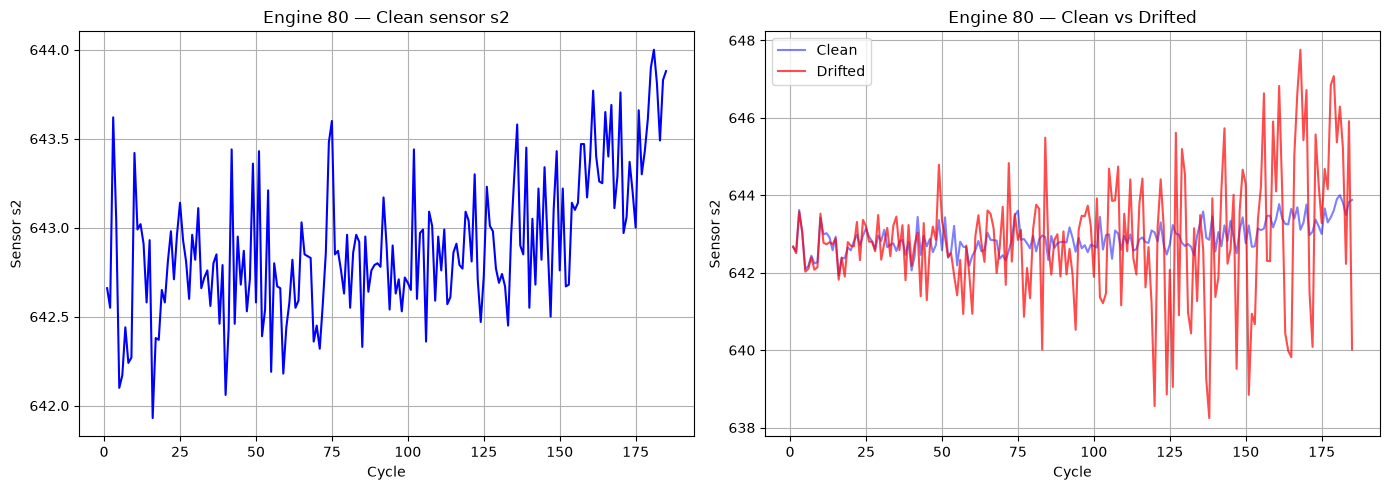

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pick one test engine
sample_engine = test_units[0]

clean = test_df[test_df['unit'] == sample_engine]
drifted = drifted_test_df[drifted_test_df['unit'] == sample_engine]

axes[0].plot(clean['cycle'], clean['s2'], label='Clean', color='blue')
axes[0].set_title(f'Engine {sample_engine} — Clean sensor s2')
axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Sensor s2')
axes[0].grid(True)

axes[1].plot(clean['cycle'], clean['s2'], label='Clean', color='blue', alpha=0.5)
axes[1].plot(drifted['cycle'], drifted['s2'], label='Drifted', color='red', alpha=0.7)
axes[1].set_title(f'Engine {sample_engine} — Clean vs Drifted')
axes[1].set_xlabel('Cycle')
axes[1].set_ylabel('Sensor s2')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../outputs/drift_simulation.png', dpi=120)
plt.show()

In [10]:
train_df.to_csv('../outputs/train_clean.csv', index=False)
drifted_test_df.to_csv('../outputs/test_drifted.csv', index=False)

print("Saved:")
print("  outputs/train_clean.csv     (", train_df.shape, ")")
print("  outputs/test_drifted.csv    (", drifted_test_df.shape, ")")

Saved:
  outputs/train_clean.csv     ( (14316, 23) )
  outputs/test_drifted.csv    ( (6315, 23) )


In [11]:
# Define feature columns (active sensors) and target
active_sensors = [col for col in df.columns if col.startswith('s')]
print(f"Using {len(active_sensors)} sensors as features")

X_train = train_df[active_sensors].values
y_train = train_df['RUL'].values

X_test_clean   = test_df[active_sensors].values
X_test_drifted = drifted_test_df[active_sensors].values

y_test = test_df['RUL'].values

print(f"X_train shape: {X_train.shape}")
print(f"X_test_drifted shape: {X_test_drifted.shape}")
print(f"y_train range: {y_train.min()} to {y_train.max()}")

Using 17 sensors as features
X_train shape: (14316, 17)
X_test_drifted shape: (6315, 17)
y_train range: 0 to 361


In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import time

# Train the static model once
print("Training static Random Forest model...")
start = time.time()

static_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
static_model.fit(X_train, y_train)

elapsed = time.time() - start
print(f"Training complete in {elapsed:.2f} seconds")

Training static Random Forest model...
Training complete in 0.40 seconds


In [13]:
# Evaluate on the CLEAN test set (to show baseline performance)
static_preds_clean = static_model.predict(X_test_clean)

static_rmse_clean = np.sqrt(mean_squared_error(y_test, static_preds_clean))
static_mae_clean  = mean_absolute_error(y_test, static_preds_clean)

print("=== Static Model on CLEAN test data ===")
print(f"RMSE: {static_rmse_clean:.2f}")
print(f"MAE:  {static_mae_clean:.2f}")

=== Static Model on CLEAN test data ===
RMSE: 44.00
MAE:  32.77


In [14]:
# Evaluate on the DRIFTED test set (this is the real-world case)
static_preds_drifted = static_model.predict(X_test_drifted)

static_rmse_drifted = np.sqrt(mean_squared_error(y_test, static_preds_drifted))
static_mae_drifted  = mean_absolute_error(y_test, static_preds_drifted)

print("=== Static Model on DRIFTED test data ===")
print(f"RMSE: {static_rmse_drifted:.2f}")
print(f"MAE:  {static_mae_drifted:.2f}")

print("\n=== Performance Degradation ===")
print(f"RMSE increase: {static_rmse_drifted - static_rmse_clean:.2f}")
print(f"Relative increase: {(static_rmse_drifted/static_rmse_clean - 1)*100:.1f}%")

=== Static Model on DRIFTED test data ===
RMSE: 70.23
MAE:  54.34

=== Performance Degradation ===
RMSE increase: 26.23
Relative increase: 59.6%


In [15]:
# Group drifted test data by cycle buckets and compute RMSE per bucket
# This is the foundation for the final comparison graph

drifted_test_df = drifted_test_df.copy()
drifted_test_df['static_pred'] = static_model.predict(X_test_drifted)
drifted_test_df['error'] = drifted_test_df['static_pred'] - drifted_test_df['RUL']
drifted_test_df['error_sq'] = drifted_test_df['error'] ** 2

# Bin cycles into ranges
bins = [0, 50, 100, 150, 200, 250, 300, 400]
drifted_test_df['cycle_bin'] = pd.cut(drifted_test_df['cycle'], bins=bins)

static_per_bin = drifted_test_df.groupby('cycle_bin', observed=True)['error_sq'].mean().apply(np.sqrt)

print("Static Model RMSE per cycle range:")
print(static_per_bin.round(2))

Static Model RMSE per cycle range:
cycle_bin
(0, 50]       64.53
(50, 100]     66.84
(100, 150]    72.31
(150, 200]    73.65
(200, 250]    77.09
(250, 300]    80.41
(300, 400]    89.95
Name: error_sq, dtype: float64


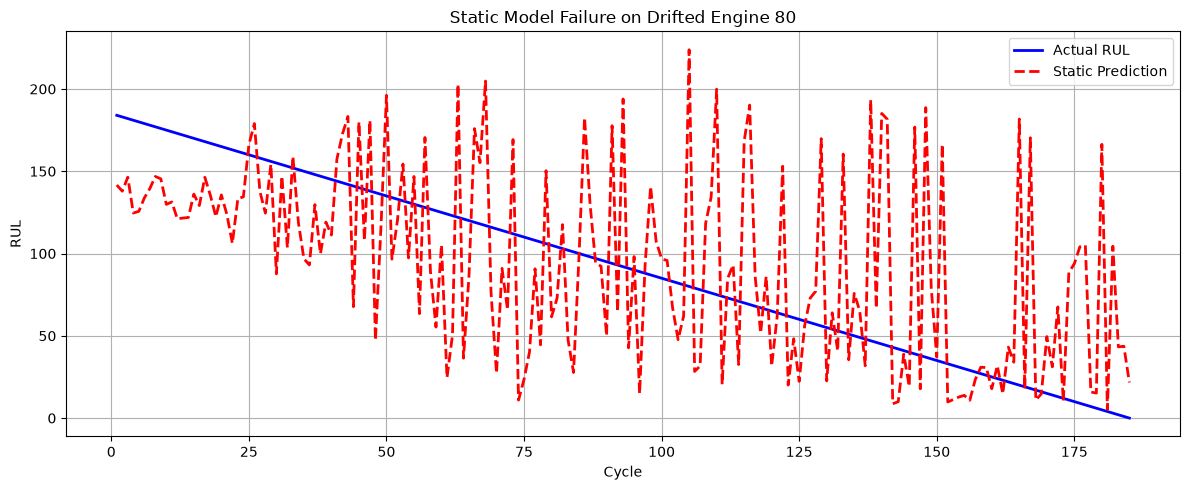

In [16]:
plt.figure(figsize=(12, 5))

# Plot actual RUL vs predicted RUL for drifted test data
sample_engine = test_units[0]
sample = drifted_test_df[drifted_test_df['unit'] == sample_engine].sort_values('cycle')

plt.plot(sample['cycle'], sample['RUL'], label='Actual RUL', color='blue', linewidth=2)
plt.plot(sample['cycle'], sample['static_pred'], label='Static Prediction', color='red', linestyle='--', linewidth=2)

plt.xlabel('Cycle')
plt.ylabel('RUL')
plt.title(f'Static Model Failure on Drifted Engine {sample_engine}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/static_model_failure.png', dpi=120)
plt.show()

In [ ]:
import pickle

# Save the static model
with open('../outputs/static_model.pkl', 'wb') as f:
    pickle.dump(static_model, f)

# Save per-bin errors for later comparison
static_per_bin.to_csv('../outputs/static_per_bin.csv')
drifted_test_df.to_csv('../outputs/test_drifted_with_static_preds.csv', index=False)

print("Saved:")
print("  outputs/static_model.pkl")
print("  outputs/static_per_bin.csv")
print("  outputs/test_drifted_with_static_preds.csv")